In [1]:
import numpy as np
import statsmodels.api as sm
from sklearn.decomposition import PCA
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import logging
from one.api import ONE
from brainbox.io.one import SessionLoader
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from collections import defaultdict
import pandas as pd
from manifold.decoding.functions.utils import check_config_decoding
import numpy as np
import pickle as pkl
from manifold.decoding.functions import nulldistributions
from communication_subspace.ibl_communication.utils import load_widefield_epoch
from tqdm import tqdm
from iblatlas.atlas import AllenAtlas
from iblatlas.regions import BrainRegions
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
import warnings
from manifold.utils import get_trial_masks
from scipy.stats import pointbiserialr
from manifold.widefield_ppi import beryl_mapping,aggregate_by_parent
from matplotlib import pyplot as plt
from glob import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psychofit as psy
from scipy import stats

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
def compute_stats_over_pseudo_ids(group, n_pseudo=200):
    """Aggregate info over pseudo_ids."""
    result = pd.Series()
    eid = group["eid"].unique()[0]
    region = group["region"].unique()[0]
    a = group.loc[group['pseudo_id'] == -1, 'score_test'].values
    b = group.loc[group['pseudo_id'] > 0, 'score_test'].values
    if len(b) != n_pseudo:
        print(f'result for {eid}-{region} does not contain {n_pseudo} pseudo-sessions')
    result['n_pseudo'] = len(b)
    if (len(a) == 0) or (len(b) != n_pseudo):
        result['score'] = np.nan
        result['p-value'] = np.nan
        result['median-null'] = np.nan
        result['n_trials'] = np.nan
    else:
        result['score'] = a[0]
        result['p-value'] = np.mean(np.concatenate([np.array(b), [a[0]]]) >= a[0])  # treat real session as pseudo
        result['median-null'] = np.median(b)
        # collect number of trials, only from real session
        c = group.loc[group['pseudo_id'] == -1, 'n_trials'].values
        n_trials = np.unique(c)
        assert len(n_trials) == 1, 'n_trials vals do not agree across all runs'
        result['n_trials'] = int(n_trials[0])
    return result


def reformat_df(df):
    """Compute mean over runs and median of null distribution; compute p-value."""

    # take mean scores over runs
    df_tmp = df.groupby(
        ['subject', 'eid', 'region', 'N_units', 'pseudo_id', 'n_trials'], as_index=False
    )['score_test'].mean()

    df_new = df_tmp.groupby(['subject', 'eid', 'region', 'N_units']).apply(
        lambda x: compute_stats_over_pseudo_ids(x)
    ).reset_index()
    df_new = df_new.rename(columns={"N_units": "n_units"})

    return df_new

In [4]:
df_all = pd.read_parquet('../data/generated/prior_sig/resultsdf_alternate.pqt')

In [5]:
df_stage_two = reformat_df(df_all)

In [6]:
# find eids where VISp is significant for prior


In [9]:
eids = df_stage_two[(df_stage_two['region']=='VISp') & (df_stage_two['p-value']<0.05) & ((df_stage_two['score']>0))]['eid'].values

In [12]:
np.save('../data/generated/temporal_prior/significant_visp_eids.npy',eids)

In [ ]:
# how strong is the prior representation in the animals , for the incongruent incorrect trials
# how strong is the prior representation in the incongruent correct trials
# train them on all congruent correct trials. 
# train them at -2
# project from -2 to 7. 


In [14]:
ss = np.load('../data/generated/temporal_prior/significant_visp_eids.npy',allow_pickle=True)

In [18]:
from pathlib import Path


zeta_pkl_path = Path("../data/generated/wifi/all_eids_dict_single_zeta_complete_wifi.pkl")

    
with open(zeta_pkl_path, "rb") as f:
    zeta_dict = pkl.load(f)

In [19]:
zeta_dict.keys()

dict_keys([UUID('f7d46a15-9498-40dc-90da-fb977ce844be'), UUID('2864dca1-38d8-464c-9777-f6fdfd5e63b5'), UUID('5102bc6c-e8d5-494b-a227-8fb15ef983ff'), UUID('b83033ed-c5d0-4e49-a595-0a04c48f059d'), UUID('501ba50d-73ba-44ec-8782-ef1fa6881044'), UUID('fa9dabe2-f6bf-4522-ba33-7d7240f9b2c9'), UUID('b69895df-382b-4d3f-bf16-f4eff019b470'), UUID('31c9782b-da54-46d0-a257-25f06bc4e5e8'), UUID('be184bc8-37fb-494c-9fcf-619b10384018'), UUID('2cdac946-3a62-458e-9060-57466f4c6bda'), UUID('6f94a278-ee23-43bd-868f-889157db8a8d'), UUID('a3695e31-7165-4d62-9e99-55f78efd5580'), UUID('9ec2bc3b-7bf1-49ca-9136-3a0eca0ac4e3'), UUID('7665dd63-7bda-430f-9425-054a2ddc3ea1'), UUID('dfe9b00e-9a20-47b0-ab1f-786f7ed827b1'), UUID('484493d0-7f05-411e-a599-c9e10a1ed287'), UUID('84565bbe-fd4c-4bdb-af55-968d46a4c424'), UUID('bf795350-d572-4a06-9ef1-999840edf0f1'), UUID('ba198a10-4918-41d7-8395-fee53eeb6a0a'), UUID('8b548e40-4bc9-41c1-a63b-d2a977b41cc0'), UUID('2c3abfbf-1871-4af0-8b8a-f337ac53b3fa'), UUID('781e1046-e4f6-46e

In [21]:
session_id = eids[0]

In [ ]:
import uuid




,goCueTrigger_times,quiescencePeriod,stimOff_times,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,probabilityLeft,feedback_times,feedbackType,rewardVolume,firstMovement_times,intervals_0,intervals_1,prior,prediction_error_left,prediction_error_right
0,36.162785,0.528058,38.029134,36.163696,36.481386,-1.0,36.162658,NaN,0.1250,0.5,36.481541,1.0,1.5,36.366546,35.545282,38.529099,0.500000,0.611852,0.388148
1,41.745723,0.499192,43.412200,41.746606,41.842224,1.0,41.745568,0.125,NaN,0.5,41.842328,1.0,1.5,41.684546,38.918099,43.912344,0.482585,0.390495,0.609505
2,45.045548,0.666302,46.862142,45.046264,45.301449,-1.0,45.045414,NaN,0.1250,0.5,45.301522,1.0,1.5,45.180546,44.318346,47.362157,0.500607,0.611253,0.388747
3,50.112179,0.548251,51.912165,50.112901,50.338181,1.0,50.112051,1.000,NaN,0.5,50.338234,1.0,1.5,50.014546,47.787357,52.412203,0.483170,0.018531,0.981469
4,54.178803,0.628702,58.045238,54.179464,55.483501,-1.0,54.178614,0.250,NaN,0.5,55.484450,-1.0,0.0,54.345546,52.806605,58.545399,0.501172,0.253827,0.746173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,4136.891534,0.646604,4139.640883,4136.892238,4138.076544,1.0,4136.891389,0.250,NaN,0.2,4138.076675,1.0,1.5,4137.729546,4136.181029,4140.140963,0.743333,0.079912,0.920088
651,4141.907965,0.490201,4143.757573,4141.908843,4142.192364,-1.0,4141.907710,NaN,1.0000,0.2,4142.192421,1.0,1.5,4141.867546,4141.100968,4144.257658,0.752272,0.893498,0.106502
652,4146.691349,0.480084,4148.507592,4146.692186,4146.950949,-1.0,4146.691242,NaN,1.0000,0.2,4146.951030,1.0,1.5,4146.830546,4145.194152,4149.007648,0.726070,0.898728,0.101272
653,4150.707856,0.414158,4152.540738,4150.708811,4150.973460,-1.0,4150.707773,NaN,1.0000,0.2,4150.973603,1.0,1.5,NaN,4149.954744,4153.040893,0.700781,0.902707,0.097293


In [24]:
trials_df = zeta_dict[uuid.UUID(session_id)]

Regions with significant prior decoding

In [28]:
bwm_df = pd.read_csv('../../ibl-partial-info-decomp/data/external/region_info.csv')

In [36]:
bwm_df[bwm_df['prior_dec_wf_sig']==True].sort_values(by='prior_dec_wf')[['Beryl','prior_dec_wf']]


,Beryl,prior_dec_wf
16,AUDv,0.000706
24,VISpor,0.000888
13,AUDd,0.001132
0,FRP,0.001814
23,VISli,0.002732
40,TEa,0.003351
22,VISpm,0.003834
21,VISpl,0.003872
15,AUDpo,0.004271
19,VISl,0.004375


In [37]:
# Mos, and maybe ssp-ul

In [3]:
from manifold.plot_decoders import load_data


df_prior = load_data('../data/generated/temporal_prior/*.pqt')

In [4]:
def aggregate_prior_all_trials(df, region='VISp'):
    """Aggregates prior decoders data"""
    time_cols = [c for c in df.columns if c.startswith('logreg_prob_f')]
    
    id_vars = [
        'session_id', 'original_trial_index', 'region', 
        'is_correct_trial', 'is_congruent', 'prior',
        'signed_contrast', 'choice','probabilityLeft'
    ]
    df_sub = df[id_vars + time_cols].copy()
    
    # Filter out unbiased blocks
    df_sub = df_sub[df_sub['probabilityLeft'] != 0.5].copy()
    
    # Filter for region
    df_sub = df_sub[df_sub['region'] == region].copy()
    
    df_sub['condition'] = np.where(df_sub['is_correct_trial'], 'Correct', 'Error')
    
    melt_ids = [
        'session_id', 'original_trial_index', 'region', 'condition', 
        'is_congruent', 'prior', 'signed_contrast', 'choice','probabilityLeft'
    ]
    
    df_melt = df_sub.melt(id_vars=melt_ids, 
                          value_vars=time_cols, 
                          var_name='frame', value_name='prob')
                          
    df_melt['time'] = df_melt['frame'].str.extract(r'f(-?\d+)').astype(int)
    
    # Align probabilities back to True Block
    df_melt['true_block'] = np.where(df_melt['prior'] > 0.5, 1, -1)
    df_melt['aligned_prob'] = np.where(df_melt['true_block'] == 1, df_melt['prob'], 1 - df_melt['prob'])
    
    return df_melt

In [5]:
df_aggregated_mos = aggregate_prior_all_trials(df_prior, region='MOs')
df_aggregated_visp = aggregate_prior_all_trials(df_prior, region='VISp')

In [298]:
def plot_population_psychometric(df_melt, target_frame=-2):

    df_f = df_melt[df_melt['time'] == target_frame].copy()
    df_f = df_f[df_f['choice'] != 0].copy()
    df_f['choice_right'] = (df_f['choice'] == 1).astype(int)
    
    if df_f['signed_contrast'].max() <= 1.0:
        df_f['signed_contrast'] = df_f['signed_contrast'] * 100
        
    df_f['decoder_bin'] = pd.cut(
        df_f['prob'], 
        bins=[0, 0.5, 1.0], 
        labels=['Left-Leaning State', 'Right-Leaning State'],
        include_lowest=True
    )
    
    x_fit = np.linspace(-100, 100, 100)
    session_fits = {'Left-Leaning State': [], 'Right-Leaning State': []}
    session_empirical = {'Left-Leaning State': [], 'Right-Leaning State': []}
    fig, ax = plt.subplots(figsize=(8,5))
    sessions = df_f['session_id'].unique()
    saved_parameters = []
    for session in sessions:
        session_parameter = []
        df_sess = df_f[df_f['session_id'] == session]

        for bin_name in ['Left-Leaning State', 'Right-Leaning State']:
            df_bin = df_sess[df_sess['decoder_bin'] == bin_name]
            
            if len(df_bin) < 10:
                # print('gg')
                continue
                
            agg = df_bin.groupby('signed_contrast')['choice_right'].agg(
                n_trials='count', prob_right='mean'
            ).reset_index()
            
            session_empirical[bin_name].append(agg)
            
            data_array = np.vstack([agg['signed_contrast'].values, 
                                    agg['n_trials'].values, 
                                    agg['prob_right'].values])
            
            try:
                pars, _ = psy.mle_fit_psycho(
                    data_array, P_model='erf_psycho_2gammas',
                    parstart=np.array([0, 20, 0.05, 0.05]),
                    parmin=np.array([-100, 5, 0, 0]),
                    parmax=np.array([100, 100, 1, 1])
                )
                y_fit = psy.erf_psycho_2gammas(pars, x_fit)
                session_fits[bin_name].append(y_fit)
                session_parameter.append(pars[0])
            except Exception:
                print('failed to converge')
                continue 
        saved_parameters.append(session_parameter)
    colors = {'Left-Leaning State': 'blue', 'Right-Leaning State': 'red'}
    for bin_name in ['Left-Leaning State', 'Right-Leaning State']:
        # Aggregate fitted curves
        fits_array = np.array(session_fits[bin_name])
        mean_fit = np.nanmean(fits_array, axis=0)
        sem_fit = stats.sem(fits_array, axis=0, nan_policy='omit')
        
        emp_df = pd.concat(session_empirical[bin_name])
        emp_agg = emp_df.groupby('signed_contrast')['prob_right'].agg(
            ['mean', 'sem', 'count']
        ).reset_index()
        
        ax.plot(x_fit, mean_fit, color=colors[bin_name], label=bin_name)
        ax.fill_between(x_fit, mean_fit - sem_fit, mean_fit + sem_fit, 
                         color=colors[bin_name], alpha=0.2)
        
        ax.errorbar(emp_agg['signed_contrast'], emp_agg['mean'], yerr=emp_agg['sem'], 
                     fmt='o', color=colors[bin_name], markersize=5, capsize=3)

    ax.axvline(0, color='k', linestyle='--', alpha=0.5)
    ax.axhline(0.5, color='k', linestyle='--', alpha=0.5)
    ax.set_xlabel('Signed Contrast')
    ax.set_ylabel('Probability of Choosing Right')
    tick_pos = [-100, -25, -12.5, -6.25, 0, 6.25, 12.5, 25, 100]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([f"{t / 100:g}" for t in tick_pos],rotation=90)
    ax.legend()
    plt.close(ax.figure) # type: ignore

    return saved_parameters, ax

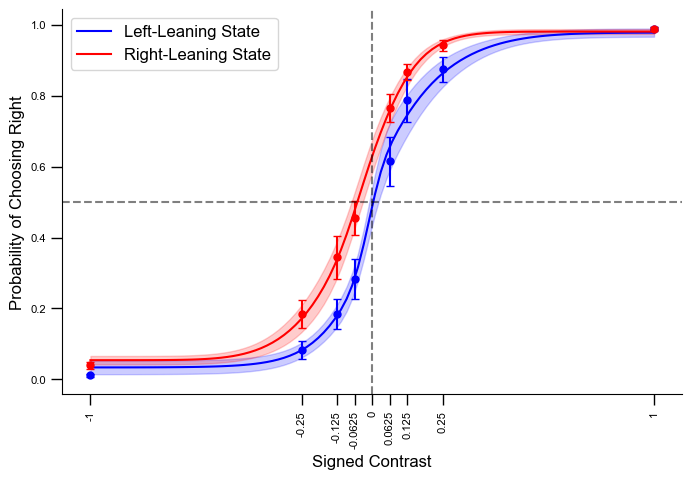

In [299]:
params, figs = plot_population_psychometric(df_aggregated_mos, 0)
figs.figure

In [333]:
saved_params_mos = []
figures_mos = []
saved_params_visp = []
figures_visp = []
for idx in df_aggregated_mos['time'].unique():
    params, figs = plot_population_psychometric(df_aggregated_mos, idx)
    saved_params_mos.append(params)
    figures_mos.append(figs)

    params, figs = plot_population_psychometric(df_aggregated_visp, idx)
    saved_params_visp.append(params)
    figures_visp.append(figs)

In [ ]:
def compute_time_deltas(saved_params):
    time_deltas = []
    for time in range(len(saved_params)):
        time_specific_sessions = saved_params[time]
        deltas = []
        for session in range(len(time_specific_sessions)):
            session_params = time_specific_sessions[session]
            if len(session_params)!=2:
                deltas.append(np.nan)
            else:
                deltas.append(session_params[0]-session_params[1])
        time_deltas.append(deltas)

    time_deltas = np.asarray(time_deltas)

    return time_deltas

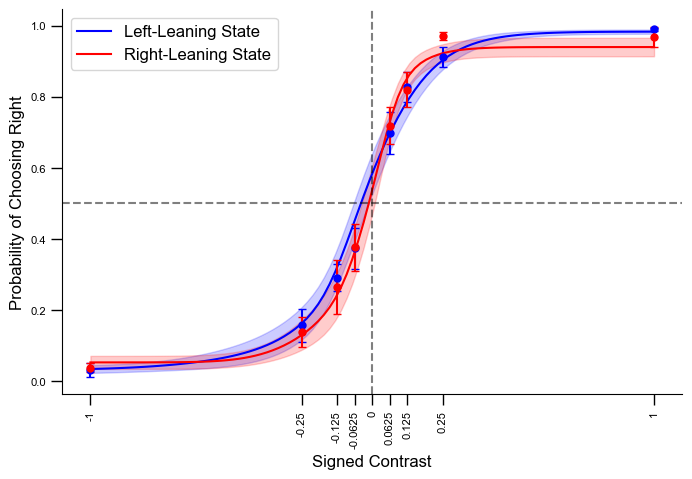

In [336]:
figures_mos[7].figure

In [228]:
time_deltas_mos = compute_time_deltas(saved_params_mos)
time_deltas_visp = compute_time_deltas(saved_params_visp)

Text(0, 0.5, 'Bias')

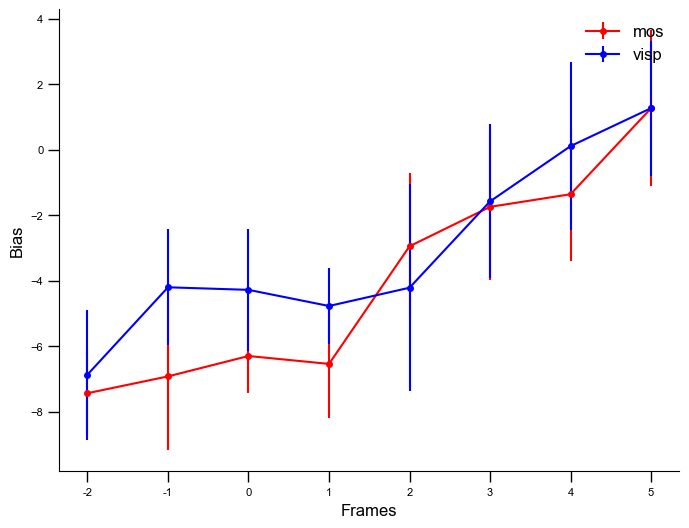

In [236]:
fig, ax = plt.subplots(figsize=(8,6))

ax.errorbar(np.arange(0,8), np.nanmean(time_deltas_mos, axis=1), yerr=np.nanstd(time_deltas_mos, axis=1)/np.sqrt(len(time_deltas_mos)), marker='o',color='r',label='mos')
ax.errorbar(np.arange(0,8), np.nanmean(time_deltas_visp, axis=1), yerr=np.nanstd(time_deltas_visp, axis=1)/np.sqrt(len(time_deltas_visp)), marker='o',color='b', label='visp')
ax.set_xticks(np.arange(0,8), np.arange(-2,6))
ax.legend(frameon=False)
ax.set_xlabel('Frames')
ax.set_ylabel('Bias')

In [327]:
def plot_folded_accuracy(df_melt, target_frame=-2, plot=False):
    
    df_f = df_melt[df_melt['time'] == target_frame].copy()
    
    df_f['abs_contrast'] = df_f['signed_contrast'].abs()
    if df_f['abs_contrast'].max() <= 1.0:
        df_f['abs_contrast'] = df_f['abs_contrast'] * 100
        
    df_f['is_correct'] = (df_f['condition'] == 'Correct').astype(int)
    
    df_f['decoder_bin'] = pd.cut(
        df_f['aligned_prob'], 
        bins=[0, 0.5, 1.0], 
        labels=['Low Alignment', 'High Alignment'],
        include_lowest=True
    )
    
    session_agg = df_f.groupby(
        ['session_id', 'is_congruent', 'decoder_bin', 'abs_contrast'], 
        observed=True
    )['is_correct'].mean().reset_index()
    
    pop_agg = session_agg.groupby(
        ['is_congruent', 'decoder_bin', 'abs_contrast'],
        observed=True
    )['is_correct'].agg(['mean', 'sem']).reset_index()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    style_map = {
        (True, 'High Alignment'): ('#4A6984', 1,'-', 'Congruent, high prior'),
        (True, 'Low Alignment'): ('#4A6984', 0.5, '-', 'Congruent, low prior'),
        (False, 'High Alignment'): ('#9C6B82', 1, '-', 'Incongruent, high prior'),
        (False, 'Low Alignment'): ('#9C6B82', 0.5, '-', 'Incongruent, low prior')
    }
    group_data_means = []
    group_data_sems = []
    labels = []
    for (is_cong, dec_bin), group_data in pop_agg.groupby(['is_congruent', 'decoder_bin'], observed=True):
        if group_data.empty:
            continue
            
        color, alpha, ls, label = style_map[(is_cong, dec_bin)]
        group_data = group_data.sort_values('abs_contrast')
        
        ax.errorbar(
            group_data['abs_contrast'], 
            group_data['mean'], 
            yerr=group_data['sem'],
            color=color, 
            linestyle=ls, 
            marker='o',
            label=label,
            capsize=3,
            markersize=5,
            alpha=alpha
        )
        group_data_means.append(group_data['mean'].values)
        group_data_sems.append(group_data['sem'].values)
        labels.append([label, dec_bin])

    ax.legend(frameon=False, loc='lower right')
        
    ax.axhline(0.5, color='k', linestyle=':', alpha=0.5)
    ax.set_xlabel('Absolute Contrast')
    ax.set_ylabel('P(Correct Choice)')
    ax.set_title(f'Frame {target_frame}')
    tick_pos = [6.25, 12.5, 25, 100]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([f"{t / 100:g}" for t in tick_pos])
    ax.set_ylim(0, 1.05)
    if not plot:
        plt.close()

    return group_data_means, group_data_sems, labels

In [328]:
# we can plot the shifts, over time. 
group_means = []
group_sems = []


for idx in df_aggregated_visp['time'].unique():
    means, sems,labels = plot_folded_accuracy(df_aggregated_visp, target_frame=idx)
    group_means.append(means)
    group_sems.append(sems)


In [337]:
group_means = np.asarray(group_means)
group_sems = np.asarray(group_sems)

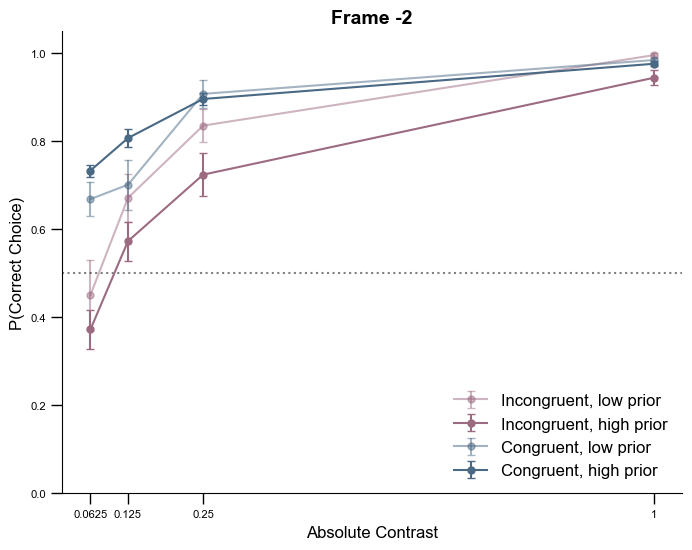

In [345]:
_, _, _ = plot_folded_accuracy(df_aggregated_visp, -2, True)

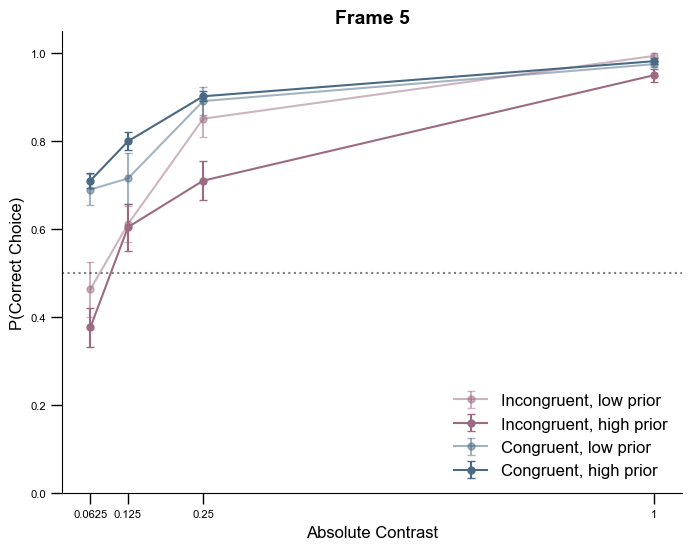

In [347]:
_, _, _ = plot_folded_accuracy(df_aggregated_visp, 5, True)

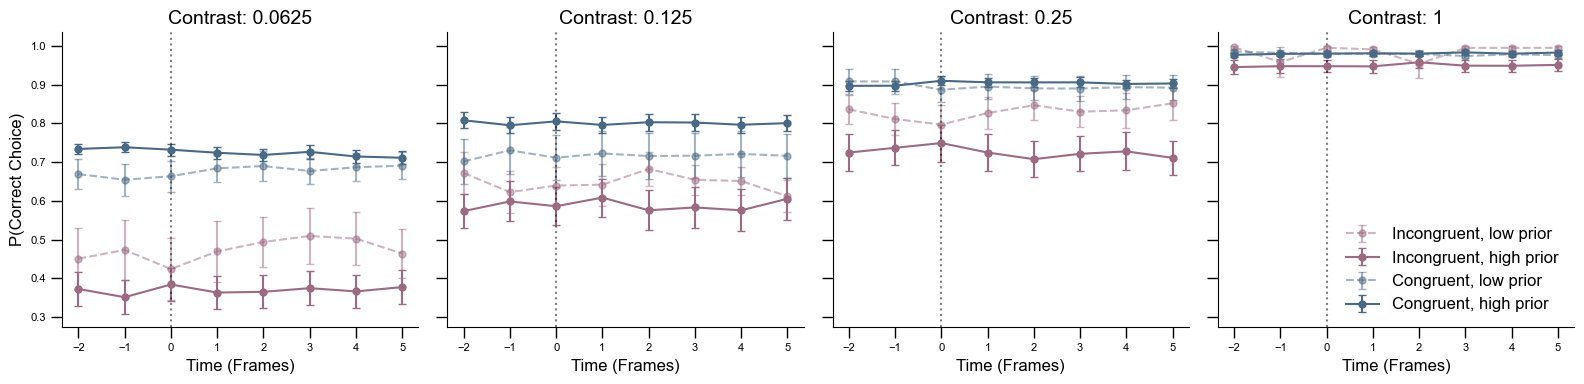

In [352]:
times = sorted(df_aggregated_visp['time'].unique())
contrasts = [6.25, 12.5, 25.0, 100.0]


fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

style_map_time = {
    'Incongruent, low prior': ('#9C6B82', 0.5, '--'),
    'Incongruent, high prior': ('#9C6B82', 1.0, '-'),
    'Congruent, low prior': ('#4A6984', 0.5, '--'),
    'Congruent, high prior': ('#4A6984', 1.0, '-')
}

for c_idx, contrast in enumerate(contrasts):
    ax = axes[c_idx]
    

    for cond_idx, label_info in enumerate(labels):
        cond_label = label_info[0]
        color, alpha, ls = style_map_time[cond_label]
        
        # group_means is indexed as [time_idx][condition_idx][contrast_idx]
        mean_series = [group_means[t][cond_idx][c_idx] for t in range(len(times))]
        sem_series = [group_sems[t][cond_idx][c_idx] for t in range(len(times))]
        
        ax.errorbar(
            times, 
            mean_series, 
            yerr=sem_series, 
            color=color, 
            alpha=alpha, 
            linestyle=ls, 
            marker='o', 
            capsize=3,
            markersize=5,
            label=cond_label
        )
        
    ax.set_title(f'Contrast: {contrast/100:g}', fontweight='normal')
    ax.set_xlabel('Time (Frames)')
    ax.axvline(0, color='k', linestyle=':', alpha=0.5) 

    if c_idx==0:
        ax.set_ylabel('P(Correct Choice)')
    if c_idx == 3:        
        # ax.axhline(0.5, color='k', linestyle=':', alpha=0.5) # Chance level
        ax.legend(frameon=False, loc='lower right')

plt.tight_layout()


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# import psychofit as psy

def plot_population_psychometric_subplots(df_melt, target_frame=-2):

    df_f = df_melt[df_melt['time'] == target_frame].copy()
    df_f = df_f[df_f['choice'] != 0].copy()
    
    # FIX 1: choice == 1 is Left. We plot the Probability of Choosing Left.
    df_f['choice_left'] = (df_f['choice'] == 1).astype(int)
    
    if df_f['signed_contrast'].max() <= 1.0:
        df_f['signed_contrast'] = df_f['signed_contrast'] * 100
        
    # FIX 2: Decoder Bins (prob < 0.5 is Right-Leaning, prob > 0.5 is Left-Leaning)
    df_f['decoder_bin'] = pd.cut(
        df_f['prob'], 
        bins=[0, 0.5, 1.0], 
        labels=['Right-Leaning', 'Left-Leaning'], 
        include_lowest=True
    )
    
    # Define True Block Bins (from 'probabilityLeft')
    p_left_vals = sorted(df_f['probabilityLeft'].dropna().unique())
    if len(p_left_vals) != 2:
        print(f"Warning: Found {len(p_left_vals)} unique probabilityLeft values. Expected 2.")
        
    block_labels = {
        p_left_vals[1]: 'Left Block',   
        p_left_vals[0]: 'Right Block'   
    }
    df_f['block_bin'] = df_f['probabilityLeft'].map(block_labels)
    
    # Setup the 4 Conditions 
    conditions = [
        ('Left Block', 'Left-Leaning'),
        ('Left Block', 'Right-Leaning'),
        ('Right Block', 'Left-Leaning'),
        ('Right Block', 'Right-Leaning')
    ]
    
    x_fit = np.linspace(-100, 100, 100)
    session_fits = {cond: [] for cond in conditions}
    session_empirical = {cond: [] for cond in conditions}
    
    # Create two subplots side-by-side, sharing the y-axis
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    ax_map = {
        'Left Block': axes[0],
        'Right Block': axes[1]
    }
    
    sessions = df_f['session_id'].unique()
    saved_parameters = []
    
    for session in sessions:
        session_parameter = {} 
        df_sess = df_f[df_f['session_id'] == session]

        for cond in conditions:
            block, decoder = cond
            df_bin = df_sess[(df_sess['block_bin'] == block) & (df_sess['decoder_bin'] == decoder)]
            
            if len(df_bin) < 10:
                session_parameter[cond] = np.nan
                continue
                
            agg = df_bin.groupby('signed_contrast')['choice_left'].agg(
                n_trials='count', prob_left='mean'
            ).reset_index()
            
            session_empirical[cond].append(agg)
            
            data_array = np.vstack([agg['signed_contrast'].values, 
                                    agg['n_trials'].values, 
                                    agg['prob_left'].values])
            
            try:
                pars, _ = psy.mle_fit_psycho(
                    data_array, P_model='erf_psycho_2gammas',
                    parstart=np.array([0, 20, 0.05, 0.05]),
                    parmin=np.array([-100, 5, 0, 0]),
                    parmax=np.array([100, 100, 1, 1])
                )
                y_fit = psy.erf_psycho_2gammas(pars, x_fit)
                session_fits[cond].append(y_fit)
                session_parameter[cond] = pars[0]  
            except Exception:
                print(f"Session {session} failed to converge for {cond}")
                session_parameter[cond] = np.nan
                continue 
                
        saved_parameters.append(session_parameter)

    # Plotting Styles
    style_map = {
        ('Left Block', 'Left-Leaning'):   {'color': 'blue', 'ls': '-',  'marker': 'o'},
        ('Left Block', 'Right-Leaning'):  {'color': 'red', 'ls': '--', 'marker': 's'},
        ('Right Block', 'Left-Leaning'):  {'color': 'blue',  'ls': '-',  'marker': 'o'},
        ('Right Block', 'Right-Leaning'): {'color': 'red',  'ls': '--', 'marker': 's'},
    }
    
    for cond in conditions:
        if len(session_fits[cond]) == 0:
            continue
            
        block, decoder = cond
        ax = ax_map[block]  
        
        fits_array = np.array(session_fits[cond])
        mean_fit = np.nanmean(fits_array, axis=0)
        sem_fit = stats.sem(fits_array, axis=0, nan_policy='omit')
        
        emp_df = pd.concat(session_empirical[cond])
        emp_agg = emp_df.groupby('signed_contrast')['prob_left'].agg(
            ['mean', 'sem', 'count']
        ).reset_index()
        
        c = style_map[cond]['color']
        ls = style_map[cond]['ls']
        m = style_map[cond]['marker']
        label_str = f"{decoder} Decoder"
        
        ax.plot(x_fit, mean_fit, color=c, linestyle=ls, label=label_str)
        ax.fill_between(x_fit, mean_fit - sem_fit, mean_fit + sem_fit, color=c, alpha=0.15)
        
        ax.errorbar(emp_agg['signed_contrast'], emp_agg['mean'], yerr=emp_agg['sem'], 
                     fmt=m, color=c, markersize=5, capsize=3)

    # Graph cleanup for both subplots
    tick_pos = [-100, -25, -12.5, -6.25, 0, 6.25, 12.5, 25, 100]
    
    for block_name, ax in ax_map.items():
        ax.axvline(0, color='k', linestyle='--', alpha=0.5)
        ax.axhline(0.5, color='k', linestyle='--', alpha=0.5)
        ax.set_xlabel('Signed Contrast')
        ax.set_title(block_name)
        ax.set_xticks(tick_pos)
        ax.set_xticklabels([f"{t / 100:g}" for t in tick_pos], rotation=90)
        ax.legend(title="Decoder State")
        
    # FIX 3: Corrected Y-Axis Label
    axes[0].set_ylabel('Probability of Choosing Left')
    
    plt.tight_layout()
    # plt.close(fig) 

    return saved_parameters#, axes

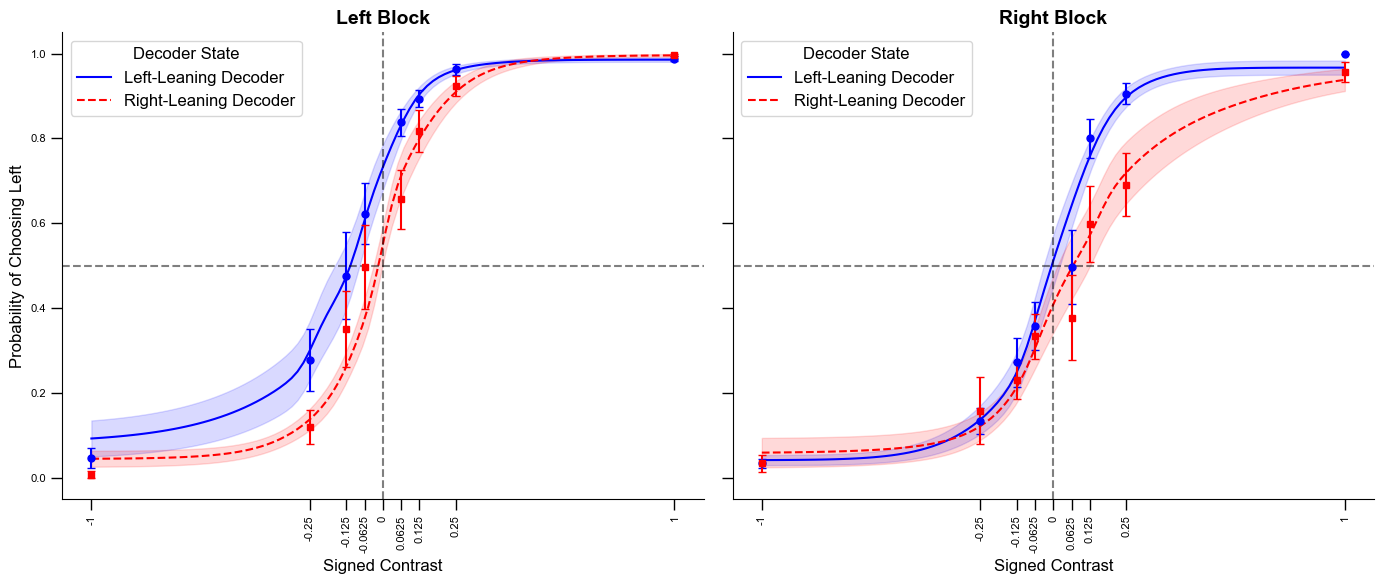

In [52]:
params = plot_population_psychometric_subplots(df_aggregated_visp,target_frame=-2)

In [54]:
from scipy.stats import wilcoxon
import statsmodels.formula.api as smf

records = []
for session_idx, session_dict in enumerate(params):
    for cond, bias_val in session_dict.items():
        if pd.notna(bias_val):  # Ignore NaN values from failed fits
            records.append({
                'session_id': session_idx,
                'block': cond[0],       # 'Left Block' or 'Right Block'
                'decoder': cond[1],     # 'Left-Leaning' or 'Right-Leaning'
                'bias': bias_val
            })

df_bias = pd.DataFrame(records)

print("--- Linear Mixed-Effects Model ---")
try:
    model = smf.mixedlm("bias ~ block * decoder", df_bias, groups=df_bias["session_id"])
    result = model.fit()
    print(result.summary())
except Exception as e:
    print(f"LMM Failed (often due to small sample size): {e}")

print("\n--- Paired Wilcoxon Tests ---")
for block_name in df_bias['block'].unique():
    # Pivot data to align paired sessions for the specific block
    df_block = df_bias[df_bias['block'] == block_name]
    df_pivot = df_block.pivot(index='session_id', columns='decoder', values='bias').dropna()
    
    if len(df_pivot) >= 5: 
        stat, pval = wilcoxon(df_pivot['Left-Leaning'], df_pivot['Right-Leaning'])
        print(f"{block_name}:")
        print(f"  N pairs: {len(df_pivot)}")
        print(f"  Mean Shift (Left-Leaning - Right-Leaning): {(df_pivot['Left-Leaning'] - df_pivot['Right-Leaning']).mean():.3f}")
        print(f"  p-value: {pval:.4f}")
    else:
        print(f"{block_name}: Not enough paired sessions (N={len(df_pivot)}) to run Wilcoxon.")

--- Linear Mixed-Effects Model ---
                          Mixed Linear Model Regression Results
Model:                         MixedLM            Dependent Variable:            bias     
No. Observations:              55                 Method:                        REML     
No. Groups:                    15                 Scale:                         109.5718 
Min. group size:               2                  Log-Likelihood:                -204.1441
Max. group size:               4                  Converged:                     Yes      
Mean group size:               3.7                                                        
------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                     -14.113    3.260 -4.329 0.000 -20.50